# Installing and using the bagelR package

## Installing bagelR

The **bagelR** package can be installed via an interactive **R** session using the following code.

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)

Using GitHub PAT from the git credential store.




Running `R CMD build`...



* checking for file ‘/tmp/Rtmp8iAy2L/remotes39a5ba7f29843b/grosed-bagel-8511657/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.0.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.0.0’

## Using bagelR

### Example 1 - detecting a change in slope

#### Load the bagel package

In [1]:
library(bagelR)


Attaching package: ‘bagelR’


The following object is masked from ‘package:stats’:

    time




#### Generate some test data

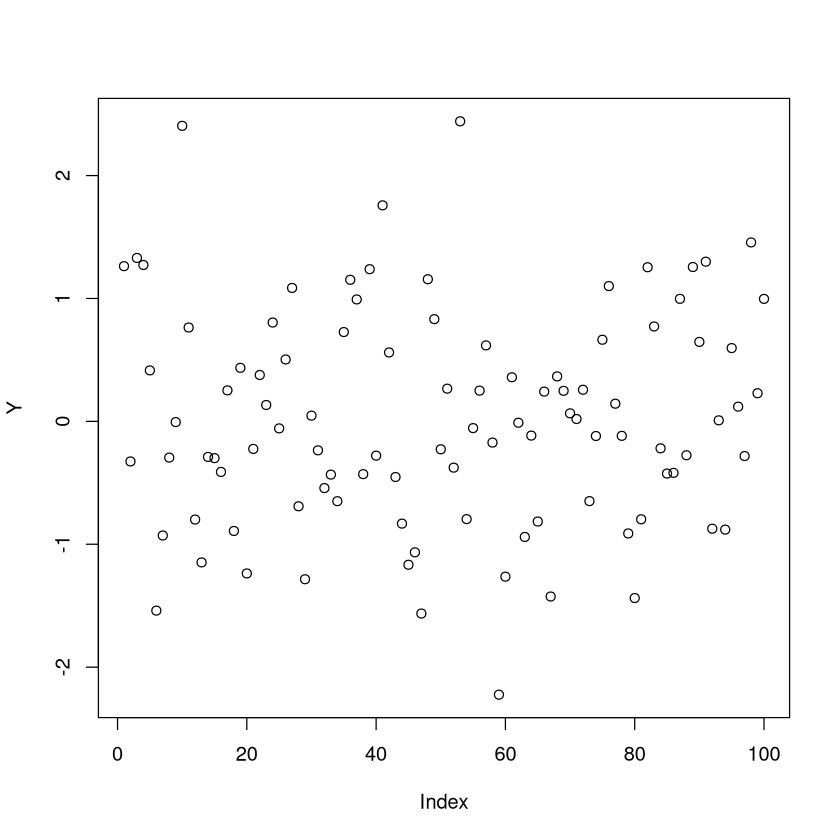

In [4]:
set.seed(0)
Y <- rnorm(100,0,1)
plot(Y)

#### Define the feature vector function

In [2]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
     M <- matrix(c(0),nc=1,nr=2)	  
     M[1,1] <- 1
     M[2,1] <- t
     return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=4)	  
    M[1,1] <- 1
    M[2,1] <- t
    if(t > tau)
    {
      M[3,1] <- 1
      M[4,1] <- t
    }
  return(M)
  }
}

#### Define the prior function

In [3]:
prior <- function(t)
{
  if(t == 1)
  {
     mu <- matrix(c(0),nc=1,nr=2)
     sigma <- diag(2)
     return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(0),nc=1,nr=4)
  sigma <- diag(4)
  sigma[3,3] <- (t-1)*(t-1)
  sigma[4,3] <- sigma[3,4] <- -(t-1)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Set model parameters 

In [4]:
p <- 1.0;
p0 <- 0.9;
s <- 1.0;
n <- 500

#### Create a new bagel model

In [5]:
model <- bagel(feature_vector,prior,p0,p,s,n)

#### Set up storage for results

In [6]:
w0s <- c()

#### Analyse the data as if running online

In [10]:
for(y in Y)
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result  
}

#### Visualise weight for tau = 0

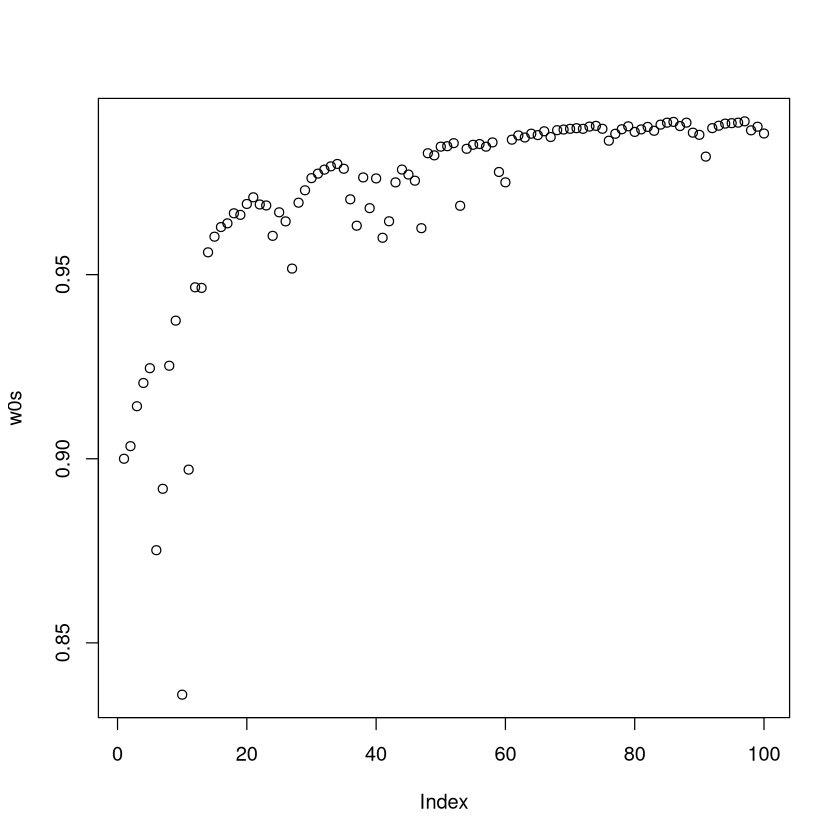

In [11]:
plot(w0s)

### Example 2

#### Generate data with change in slope

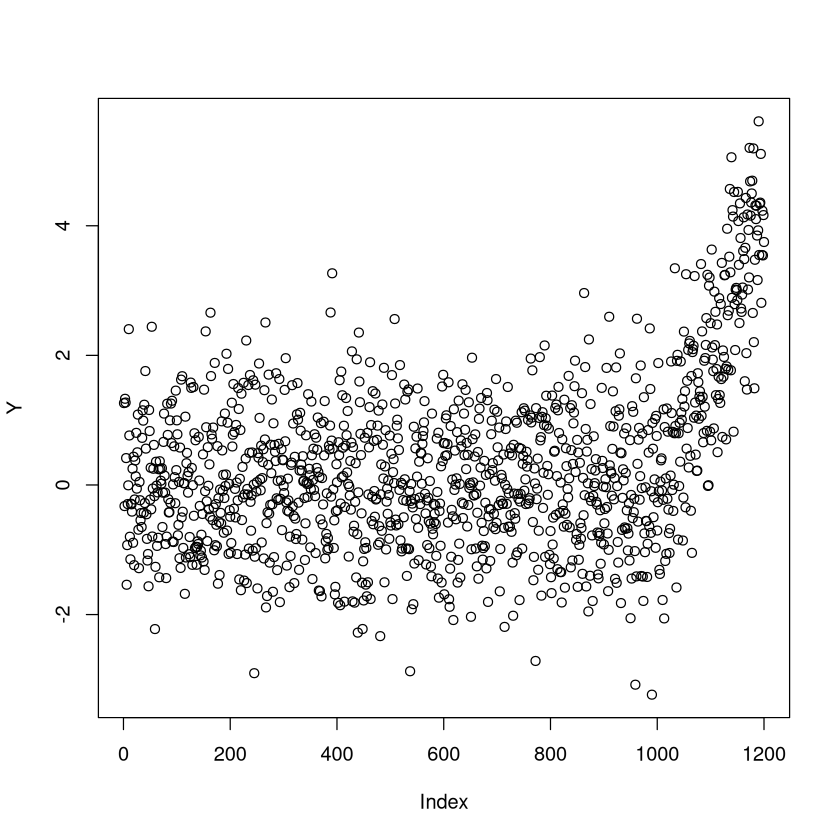

In [7]:
set.seed(0)
Y <- c(rnorm(999,0,1),seq(0,200,1)/50 + rnorm(201,0,1))
plot(Y)

In [19]:
Y <- rnorm(2000,0,1)

#### Create new model

In [8]:
model <- bagel(feature_vector,prior,p0,p,s,n)

#### Set up storage for results

In [9]:
w0s <- c()

In [10]:
for(y in Y)
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result
  if(1 - w0 > 0.8)
      break
}

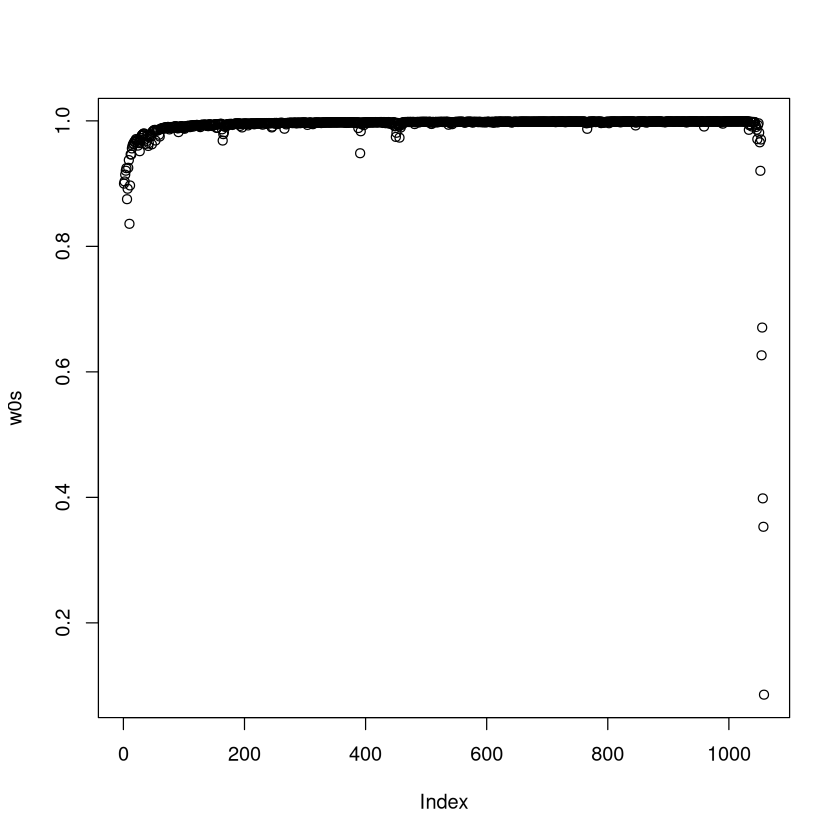

In [11]:
plot(w0s)

In [12]:
time(model)

[1] 1059

In [10]:
for(y in Y[1001:1010])
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result  
}

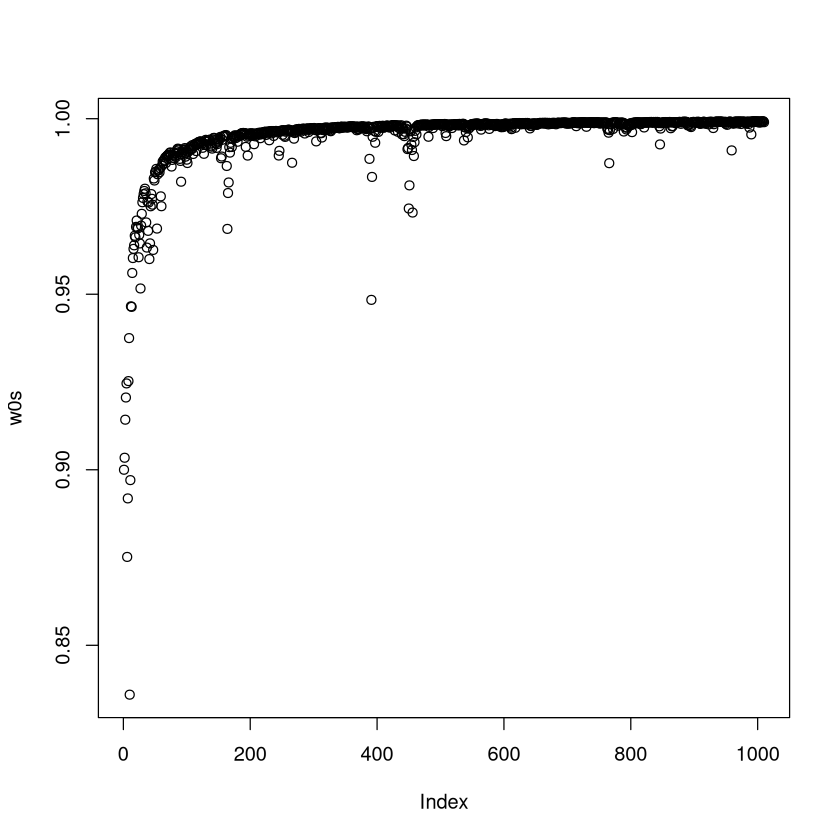

In [11]:
plot(w0s)

In [ ]:
for(y in Y[1151:1199])
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result  
}

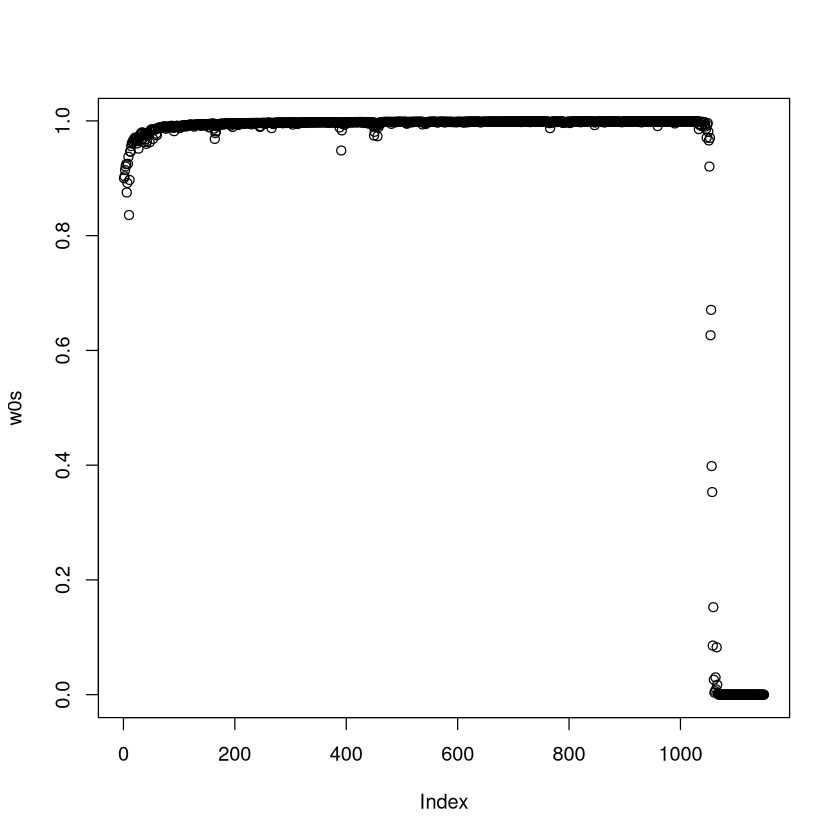

In [24]:
plot(w0s)

In [20]:
head(weights(model))

[1] 1.127726e-05 6.776543e-10 5.175242e-10 3.637534e-10 3.155428e-10
[6] 3.210511e-10

### Analyse the data as if running online

In [ ]:
for(y in Y)
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result  
}

#### Visualise weight for tau = 0

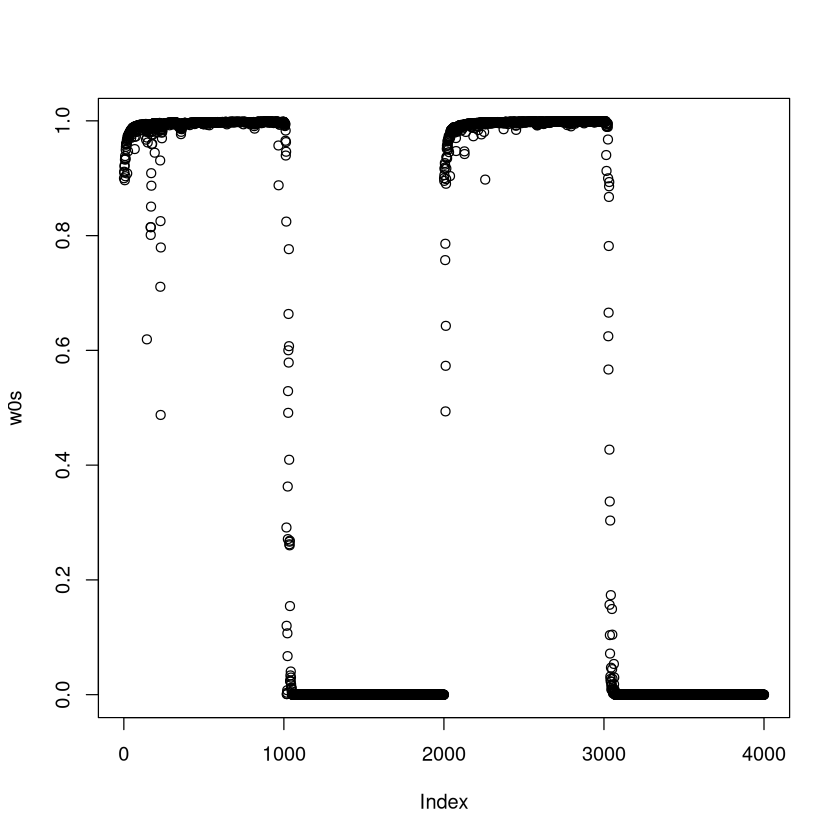

In [19]:
plot(w0s)

#### Continue with analysis

In [13]:
for(y in Y[501:1000])
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result  
}

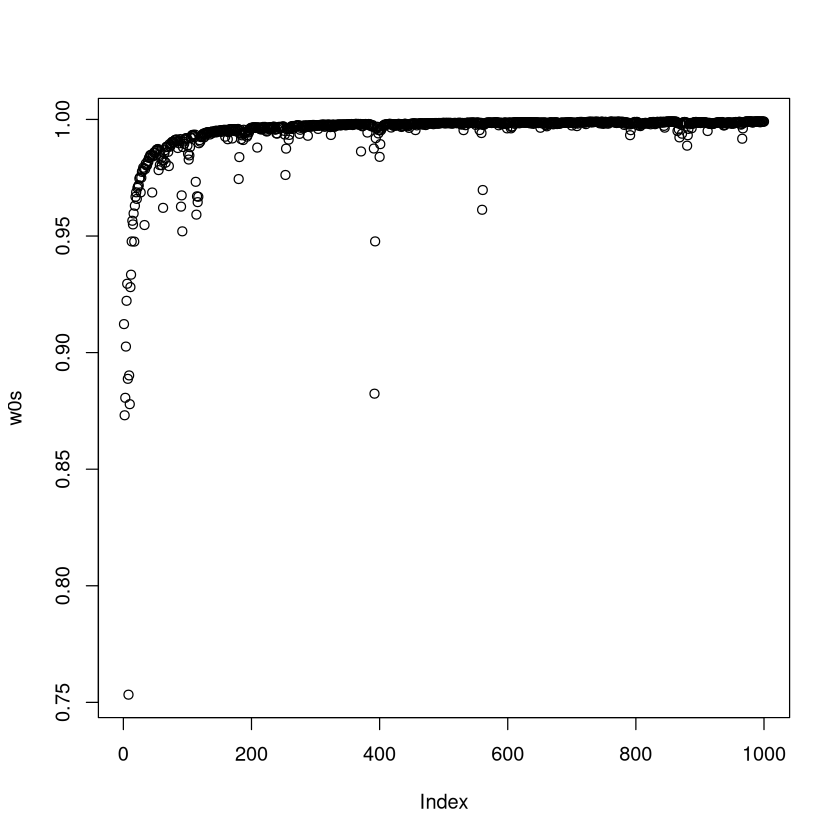

In [14]:
plot(w0s)

#### Continue with analysis

In [ ]:
for(y in Y[1001:1500])
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result  
}